### Heating Rate Analysis
2026-07-28

Aim is to vastly simplify the current analysis of circa 2024 data.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os
from scipy.optimize import curve_fit


In [106]:
### Load metadata dataframe
metadata_file = 'heating_metadata.xlsx'
metadata = pd.read_excel(metadata_file)

### Load data files
files =  metadata.loc[metadata['exclude'] == 0]['filename'].values
files = files + '.dat'
print(files)

data_folder = 'heating'

dfs = []
for file in files:
    df = pd.read_table(os.path.join(data_folder, file), delimiter=',')
    df['filename'] = file
    dfs.append(df)

# Show columns
print(dfs[1].columns)

# dfs = [dfs[0]]

['2024-03-19_L_UHfit.dat' '2024-03-21_B_UHfit.dat'
 '2024-03-21_D_UHfit.dat' '2024-03-26_B_UHfit.dat'
 '2024-03-26_C_UHfit.dat' '2024-04-03_E_UHfit.dat'
 '2024-04-03_F_UHfit.dat' '2024-04-04_C_UHfit.dat'
 '2024-04-05_C_UHfit.dat' '2024-04-10_C_UHfit.dat'
 '2024-04-10_D_UHfit.dat' '2024-05-09_M_UHfit.dat'
 '2024-05-10_R_UHfit.dat' '2024-05-10_S_UHfit.dat']
Index(['cyc', 'freq', 'amplitude', 'time', 'wait_time', 'cyc2', 'T', 'TF',
       'EF', 'EFkHz', 'ToTF', 'wx', 'wy', 'wz', 'bx', 'by', 'bz', 'q', 'mu0',
       'offs', 'fermi3', 'fermi4', 'N', 'Npix', 'ENoEF', 'EkHz', 'ENoEF2',
       'EkHz2', 'SNkB', 'tof', 'AR', 'beta_visc', 'alpha_visc', 'smomE',
       'smomEkHz', 'smomEoEFEst', 'smomEoEF', 'filename'],
      dtype='object')


In [123]:
def calculate_heating_rate(group):
    """
    Calculate heating rate from a dataframe containing time and temperature data.
    """

    total_time = group['time'].max() + group['wait_time'].min()

    initial = group[group['time']==group['time'].min()]
    final = group[group['time']==group['time'].max()]

    if group['time'].nunique() > 2:
        # Fit a linear model to the temperature vs time data
        popt, pcov = curve_fit(lambda t, a, b: a * t + b, 
                            group['time'], group['T'])
        perr = np.sqrt(np.diag(pcov)) 
    
    elif group['time'].nunique() == 2:
        # If there are only two unique time points, calculate the slope directly
        a = (final['T'].mean() - initial['T'].mean()) / (final['time'].mean() - initial['time'].mean())
        e_a = np.sqrt((final['T'].sem()**2 + initial['T'].sem()**2) / (final['time'].mean() - initial['time'].mean())**2)
        b = initial['T'].mean() - a * initial['time'].mean()
        e_b = np.sqrt(initial['T'].sem()**2 + (e_a * initial['time'].mean())**2)
        popt = [a, b]
        perr = [e_a, e_b]
    
    return pd.Series({
                    'heating_rate': popt[0], 
                    'e_heating_rate': perr[0],
                    'Ti': initial['T'].mean(),
                    'e_Ti': initial['T'].sem(),
                    'Tf': final['T'].mean(),
                    'e_Tf': final['T'].sem(),
                    'EFi': initial['EF'].mean(),
                    'e_EFi': initial['EF'].sem(),
                    'EFf': final['EF'].mean(),
                    'e_EFf': final['EF'].sem(),
                    'ToTFi': initial['ToTF'].mean(),
                    'e_ToTFi': initial['ToTF'].sem(),
                    'ToTFf': final['ToTF'].mean(),
                    'e_ToTFf': final['ToTF'].sem(),
                    'total_time': total_time,
                    'data_points': len(group),
                    })

results_df = pd.concat([
    df.groupby(['freq', 'amplitude','filename']).apply(calculate_heating_rate) for df in dfs], axis=0).reset_index()

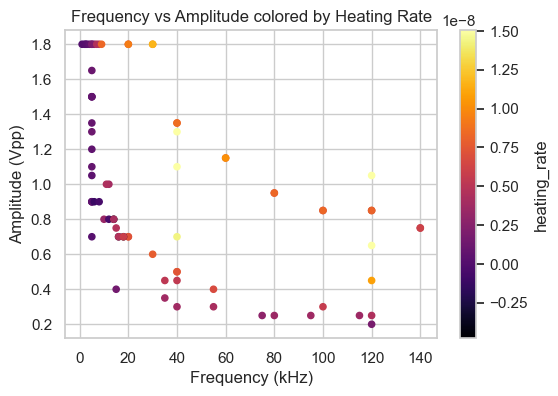

In [124]:
import matplotlib.pyplot as plt

min_heat = results_df['heating_rate'].min()
max_heat = results_df['heating_rate'].max()/4

# Create the scatter plot
scatter = results_df.plot.scatter(
    x='freq', 
    y='amplitude', 
    c='heating_rate', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
    vmin=min_heat, 
    vmax=max_heat,
)

# Label the chart
scatter.set_title('Frequency vs Amplitude colored by Heating Rate')
scatter.set_xlabel('Frequency (kHz)')
scatter.set_ylabel('Amplitude (Vpp)')

plt.show()


In [125]:
# Get the top value and its total row count
most_common_freqs = results_df['freq'].value_counts()
print(f"Frequency (kHz), # of runs: {most_common_freqs}")


Frequency (kHz), # of runs: freq
5.0      15
40.0      9
120.0     8
20.0      4
30.0      3
80.0      3
100.0     3
18.0      2
140.0     2
55.0      2
14.0      2
12.0      2
8.0       2
35.0      2
6.0       2
15.0      2
60.0      2
16.0      2
7.0       1
9.0       1
3.0       1
4.0       1
2.0       1
2.5       1
1.0       1
10.0      1
115.0     1
95.0      1
75.0      1
11.0      1
Name: count, dtype: int64


C:\Users\coldatoms\AppData\Local\Temp\ipykernel_21800\3344768652.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]


Frequency: 5.0 kHz, Fit slope: 0.0000 ± 0.0000, Intercept: 0.0000 ± 0.0000
Frequency: 40.0 kHz, Fit slope: 0.0000 ± 0.0000, Intercept: 0.0000 ± 0.0000
Frequency: 120.0 kHz, Fit slope: 0.0000 ± 0.0000, Intercept: 0.0000 ± 0.0000


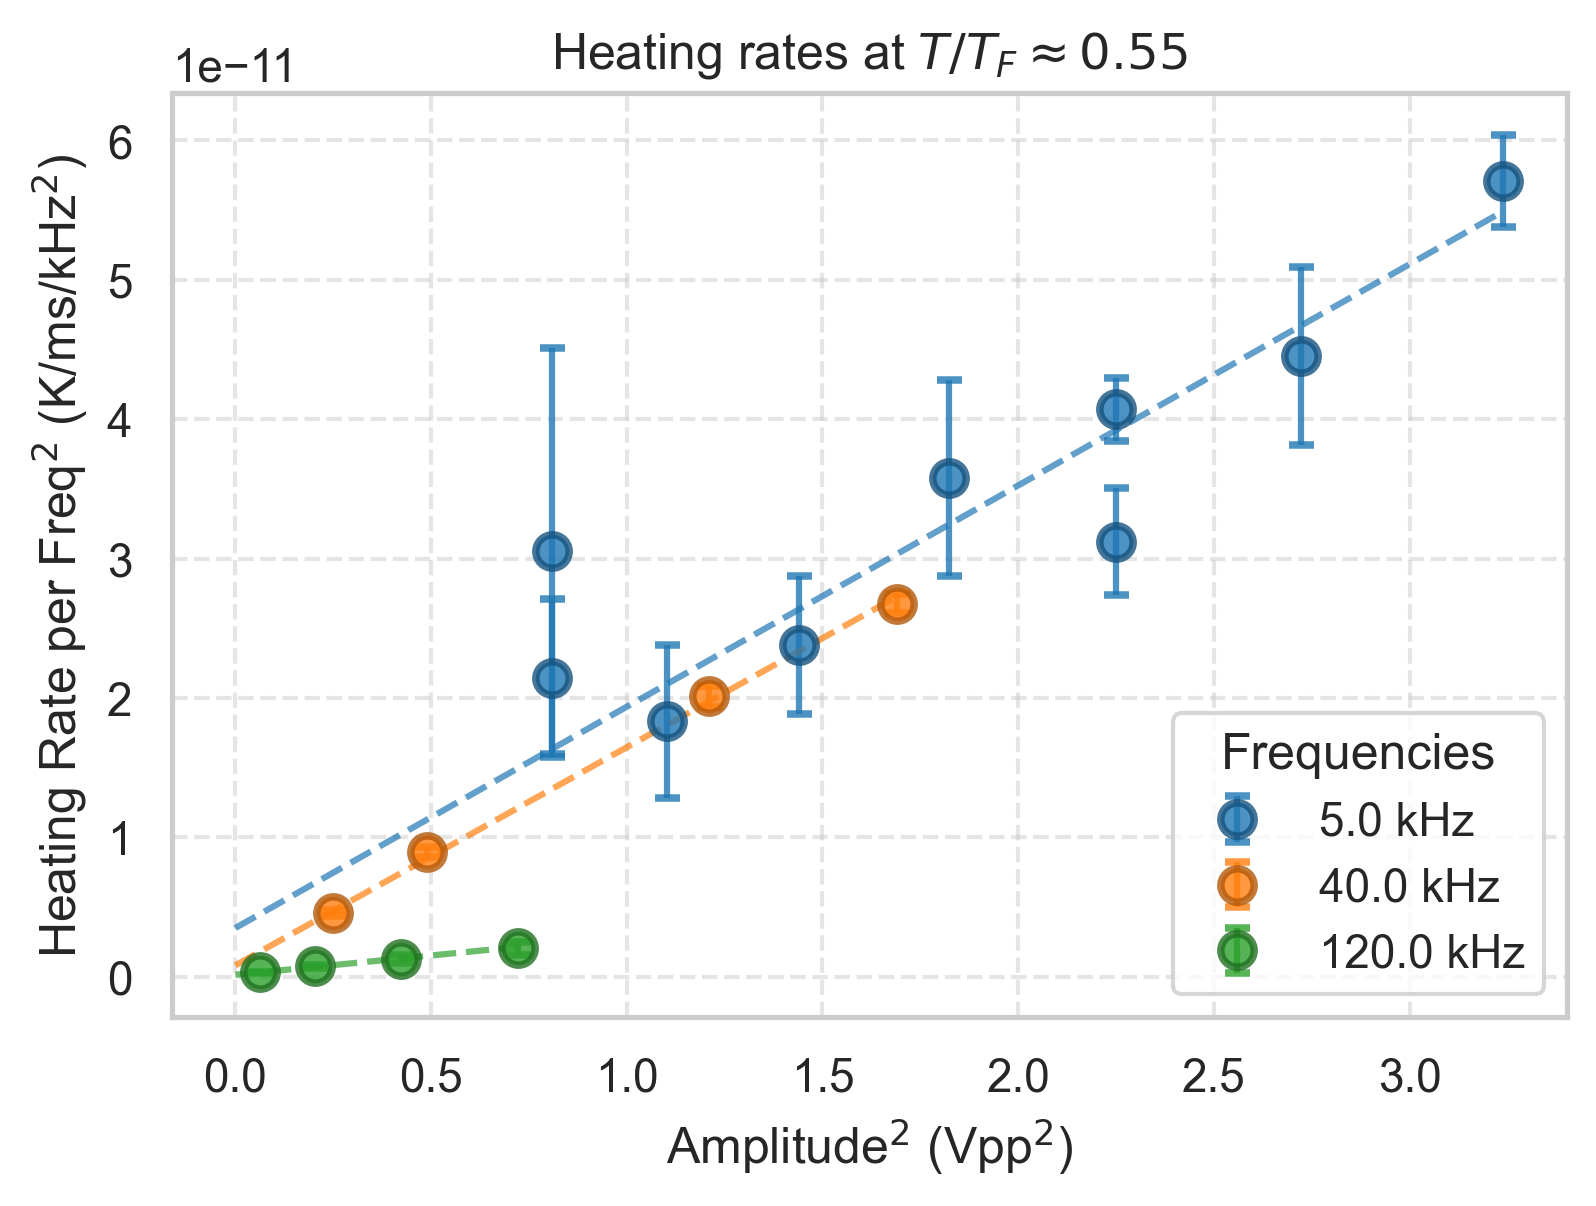

In [153]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = results_df.copy()

# Find the 3 most common frequencies
top_3_freqs = df['freq'].value_counts().nlargest(3).index

# Filter the DataFrame to keep only those 3 frequencies
df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]

# These are datasets where the initial temperature is too different from most of the others
drop_index = [73, 12, 29, 2, 47, 55, 31, 51, 59, 26]
df_plot = df_filtered.drop(index=drop_index)

# Plot each frequency group individually to assign distinct colors
plt.figure(figsize=(6, 4), dpi=300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

for i, freq_val in enumerate(top_3_freqs):
    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val]

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    plt.errorbar(
        x=group['amplitude']**2,
        y=group['heating_rate']/group['freq']**2,
        yerr=group['e_heating_rate']/group['freq']**2,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,                      # Controls marker size
        label=f'{freq_val} kHz'     # Add a label for the legend
    )

    popt, pcov = curve_fit(lambda x, m, b: m * x + b,
                            group['amplitude']**2, 
                            group['heating_rate']/group['freq']**2, 
                            sigma=group['e_heating_rate']/group['freq']**2
                           )
    perr = np.sqrt(np.diag(pcov))

    a_sqs = np.linspace(0, group['amplitude'].max()**2, 100)

    plt.plot(a_sqs, np.polyval(popt, a_sqs), color=colors[i], linestyle='--', alpha=0.7)
    
    print(f"Frequency: {freq_val} kHz, Fit slope: {popt[0]:.4f} ± {perr[0]:.4f}, Intercept: {popt[1]:.4f} ± {perr[1]:.4f}")


# Label the chart
plt.title(r'Heating rates at $T/T_F \approx 0.55$')
plt.ylabel(r'Heating Rate per Freq$^2$ (K/ms/kHz$^2$)')
plt.xlabel(r'Amplitude$^2$ (Vpp$^2$)')
plt.legend(title='Frequencies', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [150]:
df_plot[['freq','amplitude','ToTFi','heating_rate','filename']].sort_values(by=['freq','amplitude'])

,freq,amplitude,ToTFi,heating_rate,filename
18,5.0,0.90,0.580904,7.640641e-10,2024-03-26_C_UHfit.dat
38,5.0,0.90,0.592879,5.365341e-10,2024-04-05_C_UHfit.dat
39,5.0,1.05,0.609886,4.580095e-10,2024-04-05_C_UHfit.dat
40,5.0,1.20,0.610032,5.950888e-10,2024-04-05_C_UHfit.dat
41,5.0,1.35,0.592846,8.938435e-10,2024-04-05_C_UHfit.dat
34,5.0,1.50,0.598007,1.017656e-09,2024-04-03_F_UHfit.dat
42,5.0,1.50,0.579025,7.804368e-10,2024-04-05_C_UHfit.dat
43,5.0,1.65,0.572261,1.113616e-09,2024-04-05_C_UHfit.dat
44,5.0,1.80,0.556282,1.426847e-09,2024-04-05_C_UHfit.dat
13,40.0,0.50,0.520546,7.317197e-09,2024-03-26_B_UHfit.dat


TypeError: list indices must be integers or slices, not str